# Repairing Nearest Neighbor Heuristic

First we solve a given problem using the nearest neighbor heuristic, which is a common heuristic for TSP that can be arbitrarily bad.
Then we use the heuristic violating pairs from a WSPD of $s$ to guide a optimal repair over that subsection of the tour.
Finally we check the tour length against the optimal tour length to see how well the repair worked.

gr9882 having problems

In [1]:
from pathlib import Path
from typing import NamedTuple

# Set Numba/OpenMP thread env vars BEFORE importing any module that imports numba.

import numba as nb
nb.set_num_threads(1)

import tsplib95
import numpy as np
from tqdm.contrib.concurrent import thread_map, process_map

from utils.helpers import valid_tour, calc_tour_len_euc
from utils.wsp_heuristic import check_tour_with_wspd
from utils.nn import solve_nn_euc
from utils.repair_euc import repair_tour_euc
from utils.wspd_euc import get_wspd

SIZE_LIMIT = None
INT_DTYPE = np.int64
FLOAT_DTYPE = np.float64

S_TEST_VALUES = (0.25, 0.5, 0.75, 1.0, 1.25, 1.5)

### The main function

In [2]:
class RepairResult(NamedTuple):
    s: float
    bad_pair_count: int
    repair_len: float

class Result(NamedTuple):
    name: str
    size: int
    dims: int
    nn_len: float
    repair_results: list[RepairResult]
    opt_len: float

human_readable_names = {
    "name": "Problem Name",
    "size": "Number of Nodes",
    "dims": "Dimensions",
    "bad_pair_count": "Flagged Pairs",
    "nn_len": "NN Tour Length",
    "repair_len": "Repaired Tour Length",
    "opt_len": "Optimal Tour Length",
    "s": "S Factor"
}

In [3]:
# test matching EUC_2D / EUC_3D instances
def check_tour(opt_path: Path) -> Result | None:
    try:
        tsp_path = opt_path.with_suffix("").with_suffix(".tsp")  # *.opt.tour -> *.tsp
        if not tsp_path.exists():
            raise FileNotFoundError(f"Matching .tsp file not found for {opt_path}")
        
        euc_dims = 0

        prob = tsplib95.load(str(tsp_path))
        if SIZE_LIMIT is not None and prob.dimension > SIZE_LIMIT:
            return None
        if prob.edge_weight_type not in ("EUC_2D", "EUC_3D"):
            return None
            raise ValueError(f"Unsupported edge weight type {prob.edge_weight_type} in {tsp_path}")
        elif prob.edge_weight_type == "EUC_2D":
            euc_dims = 2
        elif prob.edge_weight_type == "EUC_3D":
            euc_dims = 3

        tour_prob = tsplib95.load(str(opt_path))
        if not getattr(tour_prob, "tours", None):
            raise ValueError(f"No tours found in {opt_path}")

        opt_tour = np.array(tour_prob.tours[0], dtype=INT_DTYPE) - 1

        assert len(opt_tour) == prob.dimension, f"Tour length {len(opt_tour)} does not match problem dimension {prob.dimension}"

        #print(f"Checking {prob.name} ({prob.edge_weight_type}, n={prob.dimension})...", flush=True)

        points = np.array([prob.node_coords[i] for i in prob.get_nodes()], dtype=FLOAT_DTYPE)

        nn_tour = solve_nn_euc(points, dtype=INT_DTYPE)
        
        s_results: list[RepairResult] = []
        for s in S_TEST_VALUES:
            pairs, node_ranges, indices = get_wspd(points, s, int_dtype=INT_DTYPE)
            bad_pairs = check_tour_with_wspd((pairs, node_ranges, indices), nn_tour)

            node_pairs: list[tuple[np.ndarray, np.ndarray]] = []
            for idx in bad_pairs:
                a_node, b_node, _ = pairs[idx]

                a_start, a_end = node_ranges[a_node]
                b_start, b_end = node_ranges[b_node]

                A = indices[a_start:a_end]
                B = indices[b_start:b_end]

                #print(f"Bad pair: {A} (size {len(A)}) and {B} (size {len(B)})")

                node_pairs.append((A, B))

            repair_tour = nn_tour
            for A, B in node_pairs:
                new_tour = repair_tour_euc(repair_tour, A, B, points)
                assert valid_tour(new_tour, prob.dimension), "Repaired tour is not valid"
                repair_tour = new_tour

            s_results.append(RepairResult(
                s=s,
                bad_pair_count=len(bad_pairs),
                repair_len=calc_tour_len_euc(points, repair_tour)
            ))

        return Result(
            name=prob.name,
            size=prob.dimension,
            dims=euc_dims,
            nn_len=calc_tour_len_euc(points, nn_tour),
            repair_results=s_results,
            opt_len=calc_tour_len_euc(points, opt_tour)
        )
    except Exception as e:
        raise RuntimeError(f"Error processing {opt_path}: {e}") from e

In [4]:
# Scan for all "*.opt.tour" files and 
search_roots = [Path("ALL_tsp")] # TSP_LIB_PATH, 
opt_tour_files = []

seen = set()
for root in search_roots:
    if not root.exists():
        continue
    for p in root.rglob("*.opt.tour"):
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            opt_tour_files.append(p)

opt_tour_files = sorted(opt_tour_files)
len(opt_tour_files)

220

In [5]:
# JIT warmup
dummy_points = np.random.rand(40, 2)
dummy_tour = solve_nn_euc(dummy_points, dtype=INT_DTYPE)

pairs, node_ranges, indices = get_wspd(dummy_points, 1.5, int_dtype=INT_DTYPE)
bad_pairs = check_tour_with_wspd((pairs, node_ranges, indices), dummy_tour)


# Build A, B from one valid WSPD pair (not hard-coded tiny arrays)
A = indices[node_ranges[1]['start']:node_ranges[1]['end']].astype(INT_DTYPE)
B = indices[node_ranges[2]['start']:node_ranges[2]['end']].astype(INT_DTYPE)

repair_tour_euc(dummy_tour, A, B, dummy_points), A, B

(array([33, 15,  3, 32, 23, 37, 10, 38, 31,  8,  9,  7,  2, 19, 17, 18, 20,
         4, 35,  1,  6, 25, 26, 16, 24, 36,  0, 21, 13, 29, 14, 11, 22, 39,
        30, 12, 34, 28, 27,  5]),
 array([33, 29,  5, 14, 15, 13, 21, 11, 16, 27,  0, 36, 24, 28, 26,  9, 38,
         3,  7,  8, 32, 23, 31,  2, 37, 10, 19]),
 array([34, 39, 25, 12, 22, 30, 35,  4, 17,  6,  1, 20, 18]))

In [6]:
#check_tour(opt_tour_files[147])

In [7]:
results: list[Result | None] = thread_map(check_tour, opt_tour_files, max_workers=4)

  0%|          | 0/220 [00:00<?, ?it/s]

/Users/addisonhanrattie/Documents/tsp_wsp_hardness.nosync/utils/repair_euc.py:180: NumbaTypeSafetyWarning: unsafe cast from int64 to uint32. Precision may be lost.
  curr_path_internal.append(active_nodes[curr_u])


KeyboardInterrupt: 

### TSPLIB Names

In [8]:
search_roots = [Path("TSPLIB")]
opt_tour_files = []

seen = set()
for root in search_roots:
    if not root.exists():
        continue
    for p in root.rglob("*.tsp"):
        rp = p.resolve()
        if rp not in seen:
            seen.add(rp)
            opt_tour_files.append(p)

opt_tour_files = sorted(opt_tour_files)
tsplib_prob_names = [p.stem for p in opt_tour_files]

## Analysis of results

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import scienceplots
plt.style.use(['science', 'ieee', 'high-contrast'])

In [19]:
# 1. Filter out Nones and create the initial DataFrame
valid_results = [r for r in results if r is not None]
df = pd.DataFrame(valid_results)

# 2. Explode the list of RepairResults so each one gets its own row
df = df.explode('repair_results').reset_index(drop=True)

# 3. Expand the RepairResult NamedTuples into separate columns
# (Since NamedTuples act like standard tuples, we convert them to dicts first)
repair_df = pd.DataFrame(
    df['repair_results'].apply(lambda x: x._asdict() if pd.notnull(x) else {})
    .tolist(), 
    index=df.index
)

# 4. Drop the old nested column and join the new flat columns
df = df.drop(columns=['repair_results']).join(repair_df)
df.to_csv("nn_repair_results.csv", index=False)

NameError: name 'results' is not defined

In [10]:
df = pd.read_csv("nn_repair_results.csv")

In [11]:
df_tsplib = df[df['name'].isin(tsplib_prob_names)]
df_tsplib

,name,size,dims,nn_len,opt_len,s,bad_pair_count,repair_len
300,a280,280,2,3157.0,2579.0,0.25,5,3155.0
301,a280,280,2,3157.0,2579.0,0.50,0,3157.0
302,a280,280,2,3157.0,2579.0,0.75,0,3157.0
303,a280,280,2,3157.0,2579.0,1.00,0,3157.0
304,a280,280,2,3157.0,2579.0,1.25,0,3157.0
...,...,...,...,...,...,...,...,...
1045,vm1748,1748,2,408101.0,336555.0,0.50,1,408075.0
1046,vm1748,1748,2,408101.0,336555.0,0.75,0,408101.0
1047,vm1748,1748,2,408101.0,336555.0,1.00,0,408101.0
1048,vm1748,1748,2,408101.0,336555.0,1.25,0,408101.0


In [12]:
df_15 = df_tsplib[df_tsplib['s'] == 1.5]

/var/folders/_t/4_m8pb3d3xs763zf2ztl10k40000gn/T/ipykernel_94214/3137668497.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  bad_count_df = df_15[df.bad_pair_count > 0].copy()


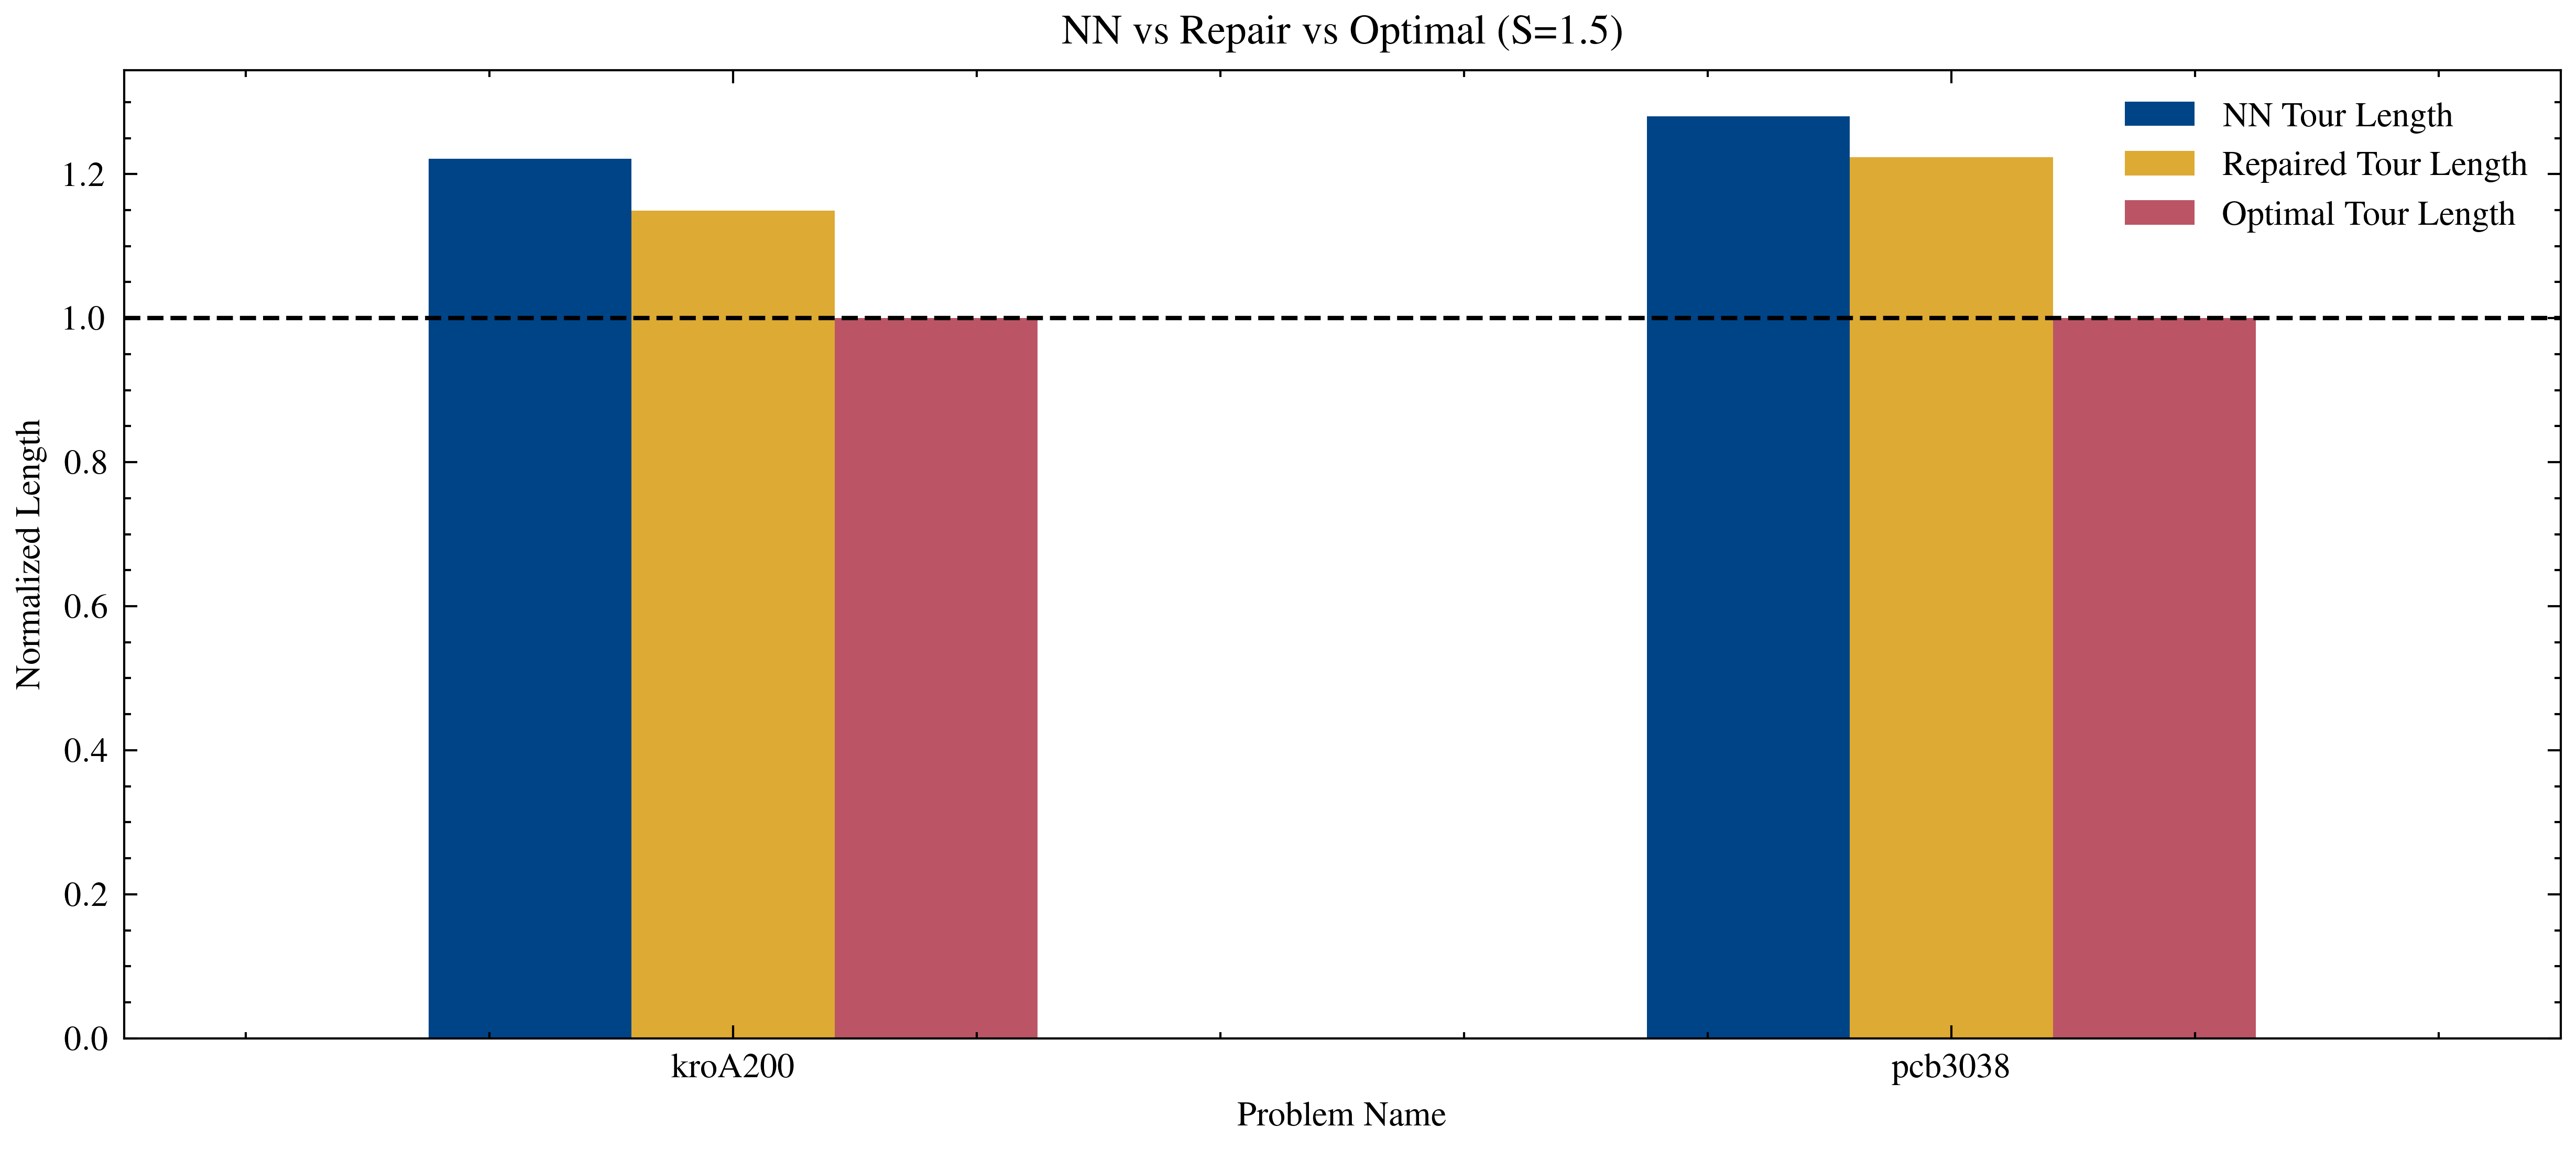

In [13]:
# drop those with no bad pairs
bad_count_df = df_15[df.bad_pair_count > 0].copy()

pct_df = bad_count_df[["nn_len", "repair_len", "opt_len"]].div(bad_count_df["opt_len"], axis=0)

pct_df["name"] = bad_count_df["name"]
pct_df.set_index("name", inplace=True)
ax = pct_df.rename(columns=human_readable_names).plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_xlabel("Problem Name")
ax.set_ylabel("Normalized Length")
ax.set_title("NN vs Repair vs Optimal (S=1.5)")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1)


In [29]:
# optimality reduction

1 - ((pct_df - 1)["repair_len"] / (pct_df - 1)["nn_len"])

name
kroA200    0.323987
pcb3038    0.204345
dtype: float64